<a href="https://colab.research.google.com/github/thienandinh29/nghiemcuukhoahocsgu2026/blob/main/Experiment_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Tải dữ liệu đã chia (Train 80% / Test 20%)
train_df = pd.read_csv('sp500_train_80.csv', index_col='Date', parse_dates=True)
test_df = pd.read_csv('sp500_test_20.csv', index_col='Date', parse_dates=True)

# 2. Tách Features (X) và Target (y) - Bài toán dự báo 1 ngày
# Bỏ cột Target_5D đi vì ta đang focus vào Target_1D
X_train = train_df.drop(columns=['Target_1D', 'Target_5D'])
y_train = train_df['Target_1D']

X_test = test_df.drop(columns=['Target_1D', 'Target_5D'])
y_test = test_df['Target_1D']

# 3. Khởi tạo danh sách các mô hình
models = {
    "1. Baseline: Logistic Regression": LogisticRegression(random_state=42),
    "2. Support Vector Machine (SVM)": SVC(random_state=42),
    "3. Ensemble: Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "4. Ensemble: XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 4. Huấn luyện và Đánh giá hàng loạt
results = []

for name, model in models.items():
    print(f"Đang huấn luyện {name}...")
    # Huấn luyện (Fit)
    model.fit(X_train, y_train)

    # Dự báo trên tập Test
    y_pred = model.predict(X_test)

    # Đo lường hiệu suất
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Lưu kết quả
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# 5. Hiển thị Bảng xếp hạng các mô hình
results_df = pd.DataFrame(results)
print("\n=== BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ ===")
print(results_df.to_string(index=False))

Đang huấn luyện 1. Baseline: Logistic Regression...
Đang huấn luyện 2. Support Vector Machine (SVM)...
Đang huấn luyện 3. Ensemble: Random Forest...
Đang huấn luyện 4. Ensemble: XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:16:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ ===
                           Model  Accuracy  Precision  Recall  F1-Score
1. Baseline: Logistic Regression    0.5346     0.5625  0.7570    0.6454
 2. Support Vector Machine (SVM)    0.5007     0.5567  0.5280    0.5420
      3. Ensemble: Random Forest    0.4654     0.5590  0.2103    0.3056
            4. Ensemble: XGBoost    0.4627     0.5509  0.2150    0.3092



=== PHÂN TÍCH CHI TIẾT: 1. Baseline: Logistic Regression ===


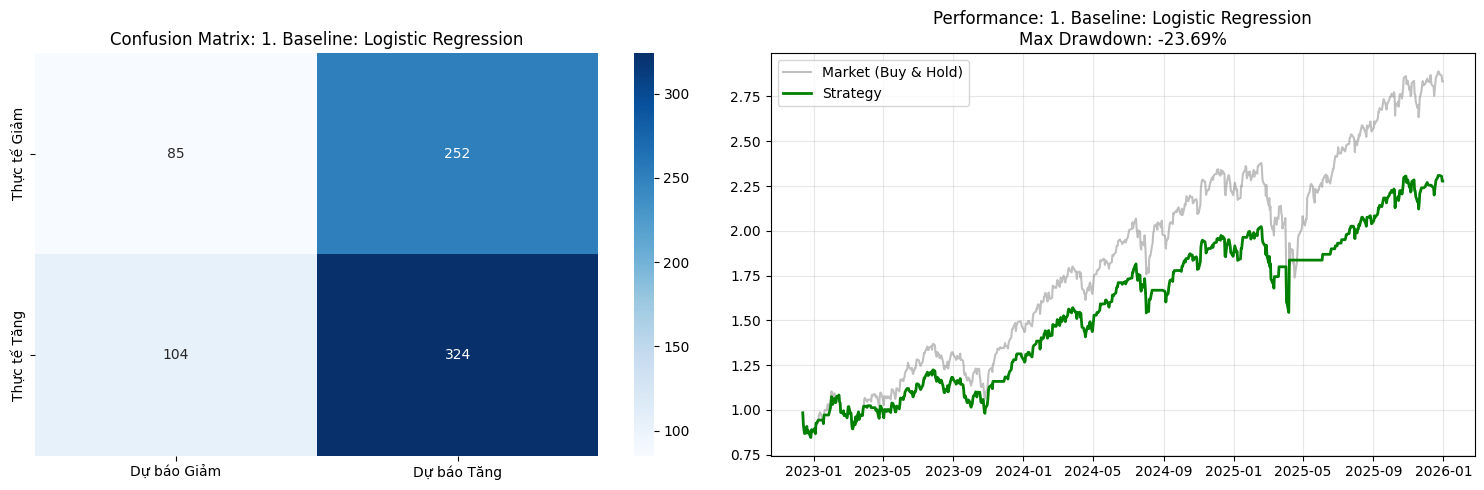

Max Drawdown: -23.69%
Classification Report:
              precision    recall  f1-score   support

        Giảm       0.45      0.25      0.32       337
        Tăng       0.56      0.76      0.65       428

    accuracy                           0.53       765
   macro avg       0.51      0.50      0.48       765
weighted avg       0.51      0.53      0.50       765


=== PHÂN TÍCH CHI TIẾT: 2. Support Vector Machine (SVM) ===


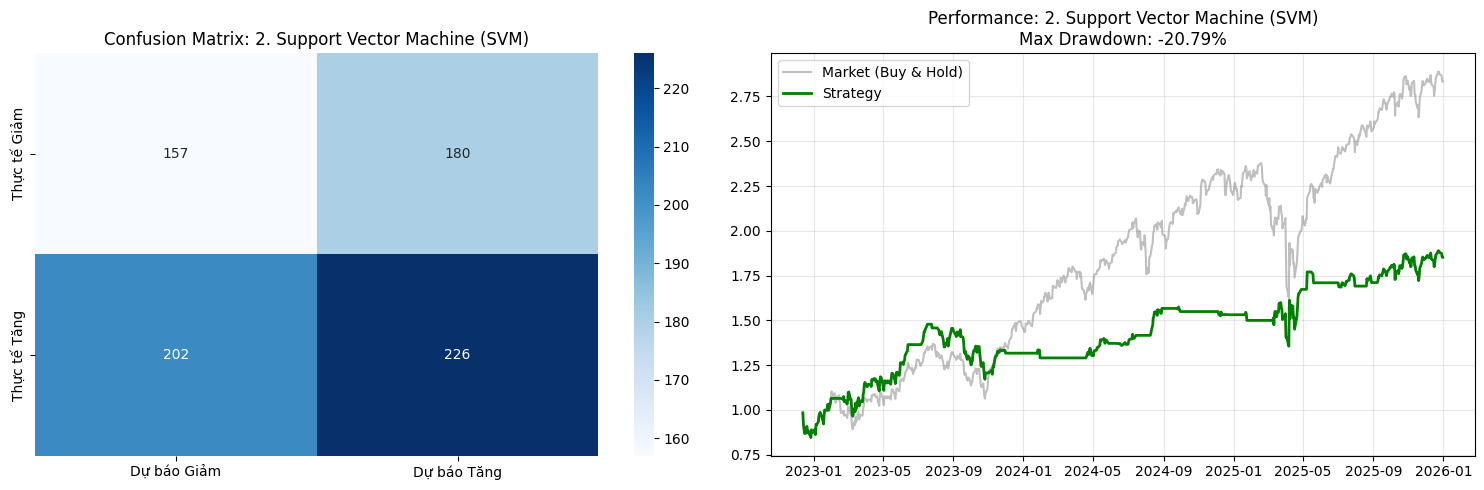

Max Drawdown: -20.79%
Classification Report:
              precision    recall  f1-score   support

        Giảm       0.44      0.47      0.45       337
        Tăng       0.56      0.53      0.54       428

    accuracy                           0.50       765
   macro avg       0.50      0.50      0.50       765
weighted avg       0.50      0.50      0.50       765


=== PHÂN TÍCH CHI TIẾT: 3. Ensemble: Random Forest ===


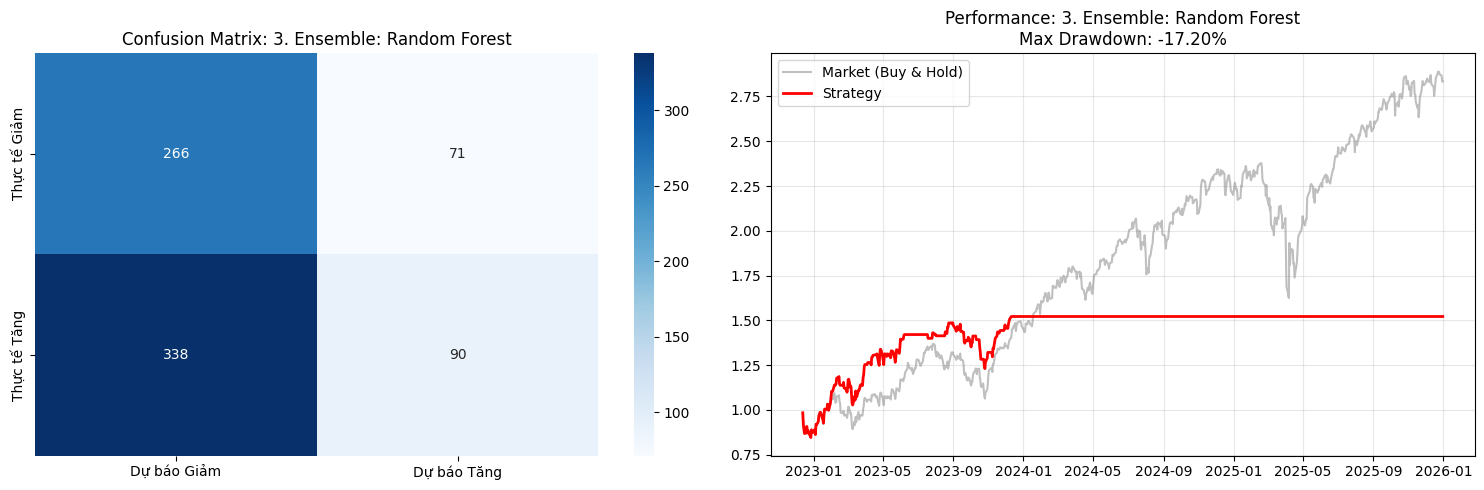

Max Drawdown: -17.20%
Classification Report:
              precision    recall  f1-score   support

        Giảm       0.44      0.79      0.57       337
        Tăng       0.56      0.21      0.31       428

    accuracy                           0.47       765
   macro avg       0.50      0.50      0.44       765
weighted avg       0.51      0.47      0.42       765


=== PHÂN TÍCH CHI TIẾT: 4. Ensemble: XGBoost ===


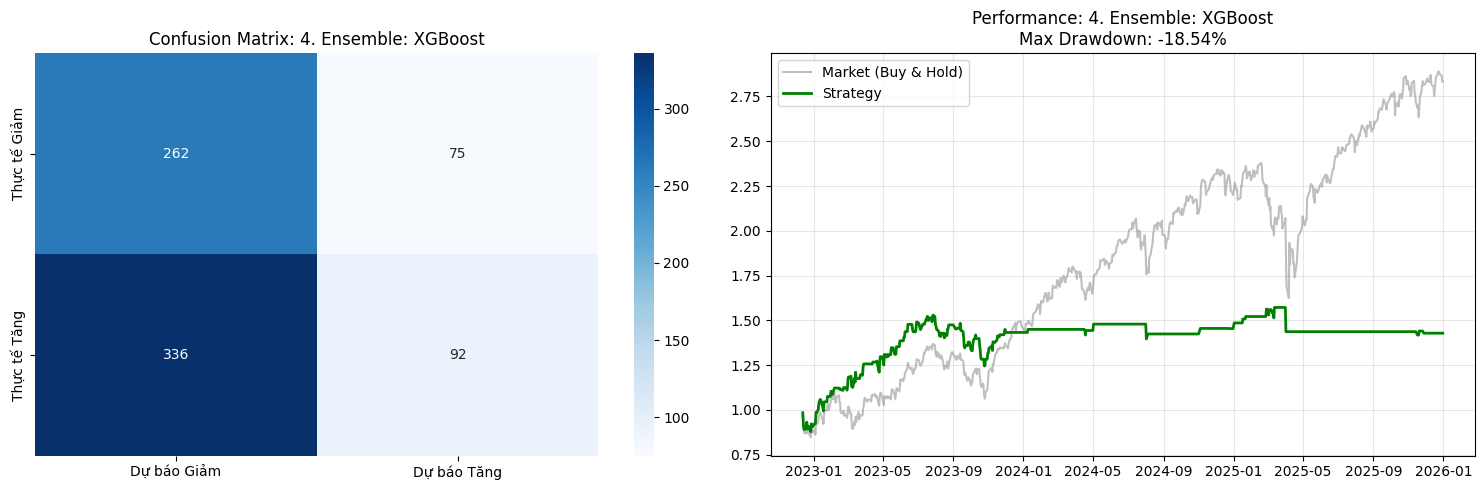

Max Drawdown: -18.54%
Classification Report:
              precision    recall  f1-score   support

        Giảm       0.44      0.78      0.56       337
        Tăng       0.55      0.21      0.31       428

    accuracy                           0.46       765
   macro avg       0.49      0.50      0.43       765
weighted avg       0.50      0.46      0.42       765



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Tính toán tỷ suất sinh lời thực tế của thị trường (Benchmark)
real_returns = test_df['Close'].pct_change().shift(-1)
real_returns.fillna(0, inplace=True)
cumulative_market = (1 + real_returns).cumprod()

# 2. Vòng lặp qua tất cả các mô hình
for name, model in models.items():
    print(f"\n=== PHÂN TÍCH CHI TIẾT: {name} ===")

    # Dự báo trên tập Test
    y_pred_test = model.predict(X_test)

    # TẠO MA TRẬN NHẦM LẪN
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Dự báo Giảm', 'Dự báo Tăng'],
                yticklabels=['Thực tế Giảm', 'Thực tế Tăng'], ax=ax1)
    ax1.set_title(f'Confusion Matrix: {name}')

    # KIỂM ĐỊNH THỰC CHIẾN
    strategy_returns = y_pred_test * real_returns
    cumulative_strategy = (1 + strategy_returns).cumprod()

    # Max Drawdown
    rolling_max = cumulative_strategy.cummax()
    drawdown = cumulative_strategy / rolling_max - 1.0
    max_drawdown = drawdown.min()

    # Vẽ biểu đồ Equity Curve
    ax2.plot(test_df.index, cumulative_market, label='Market (Buy & Hold)', color='gray', alpha=0.5)
    ax2.plot(test_df.index, cumulative_strategy, label='Strategy', color='green' if 'Random' not in name else 'red', linewidth=2)
    ax2.set_title(f'Performance: {name}\nMax Drawdown: {max_drawdown:.2%}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Max Drawdown: {max_drawdown:.2%}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_test, target_names=['Giảm', 'Tăng'], zero_division=0))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Định nghĩa lưới không gian siêu tham số (Hyperparameter Grid)
# Đây là các ranh giới mà thuật toán Random Search sẽ đi "mò" ngẫu nhiên
param_dist = {
    'n_estimators': [100, 200, 300, 500],        # Số lượng cây quyết định
    'max_depth': [5, 10, 15, 20, None],          # Độ sâu tối đa của cây (Giảm xuống để chống Overfitting)
    'min_samples_split': [2, 5, 10, 20],         # Số lượng mẫu tối thiểu để tách một nhánh
    'min_samples_leaf': [1, 2, 4, 10],           # Số lượng mẫu tối thiểu ở lá cuối cùng
    'max_features': ['sqrt', 'log2', None]       # Số lượng đặc trưng xem xét mỗi lần tách
}

print("Đang khởi tạo Random Search... Quá trình này có thể mất vài phút.")

# 2. Khởi tạo mô hình cơ sở
rf_base = RandomForestClassifier(random_state=42)

# 3. Cấu hình RandomizedSearchCV
# n_iter = 20: Sẽ thử ngẫu nhiên 20 tổ hợp tham số khác nhau (Tăng lên 50 hoặc 100 nếu máy bạn mạnh)
# cv = 5: Cross-validation 5 folds trên tập Train để đảm bảo tính khách quan
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',           # Tối ưu hóa chỉ số F1-Score (Cân bằng giữa Precision và Recall)
    cv=5,
    verbose=2,              # Hiển thị log tiến độ chạy
    random_state=42,
    n_jobs=-1               # Dùng toàn bộ lõi CPU để chạy cho nhanh
)

# 4. Bắt đầu tìm kiếm trên tập Train
# (Đảm bảo X_train và y_train đã có sẵn trên bộ nhớ từ cell trước)
random_search.fit(X_train, y_train)

# 5. Kết xuất Mô hình tốt nhất (Best Model)
best_rf_model = random_search.best_estimator_

print("\n" + "="*50)
print("🎯 ĐÃ TÌM THẤY BỘ THAM SỐ TỐI ƯU NHẤT:")
print(random_search.best_params_)
print("="*50 + "\n")

# 6. Đánh giá lại trên tập Test (Thực chiến Out-of-sample)
y_pred_tuned = best_rf_model.predict(X_test)

print("BÁO CÁO MÔ HÌNH SAU KHI TUNING (TRÊN TẬP TEST CHƯA TỪNG THẤY):")
print(classification_report(y_test, y_pred_tuned, target_names=['Giảm', 'Tăng']))

# So sánh nhanh với mô hình cũ
old_acc = accuracy_score(y_test, y_pred_test) # y_pred_test là kết quả từ mô hình chưa tune ở bước trước
new_acc = accuracy_score(y_test, y_pred_tuned)

print(f"Độ chính xác (Accuracy) TRƯỚC khi Tune: {old_acc:.4%}")
print(f"Độ chính xác (Accuracy) SAU khi Tune:   {new_acc:.4%}")

Đang khởi tạo Random Search... Quá trình này có thể mất vài phút.
Fitting 5 folds for each of 20 candidates, totalling 100 fits

🎯 ĐÃ TÌM THẤY BỘ THAM SỐ TỐI ƯU NHẤT:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}

BÁO CÁO MÔ HÌNH SAU KHI TUNING (TRÊN TẬP TEST CHƯA TỪNG THẤY):
              precision    recall  f1-score   support

        Giảm       0.43      0.66      0.52       337
        Tăng       0.53      0.31      0.39       428

    accuracy                           0.46       765
   macro avg       0.48      0.48      0.45       765
weighted avg       0.49      0.46      0.45       765

Độ chính xác (Accuracy) TRƯỚC khi Tune: 46.2745%
Độ chính xác (Accuracy) SAU khi Tune:   46.1438%


In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score

# 1. Khởi tạo mô hình XGBoost cơ bản
# Code mới đã sửa
xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)
# 2. Xây dựng Lưới Siêu tham số cho XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],     # Số lượng cây (Trees)
    'max_depth': [3, 5, 7, 9],                # Độ sâu của cây (Giảm xuống để chống học vẹt)
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Tốc độ học (Nếu n_estimators lớn, learning_rate nên nhỏ)
    'subsample': [0.6, 0.8, 1.0],             # Tỷ lệ lấy mẫu dữ liệu cho từng cây
    'colsample_bytree': [0.6, 0.8, 1.0],      # Tỷ lệ lấy mẫu đặc trưng (cột) cho từng cây
    'gamma': [0, 0.1, 0.5, 1, 5]              # Hệ số trừng phạt việc tạo thêm nhánh mới
}

print("Đang chạy Random Search cho XGBoost...")
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=20,          # Thử ngẫu nhiên 20 tổ hợp (tăng lên nếu muốn dò kỹ hơn)
    scoring='f1',       # Tối ưu hóa F1-Score
    cv=5,               # Cross-validation 5 Folds
    verbose=1,
    random_state=42,
    n_jobs=-1           # Tận dụng tối đa CPU
)

# 3. Fit dữ liệu vào quá trình dò tìm (Lưu ý: Dùng X_train, y_train từ cell trước)
xgb_random_search.fit(X_train, y_train)

# 4. Xuất kết quả tốt nhất
best_xgb_model = xgb_random_search.best_estimator_
print("\n[XGBoost] Bộ tham số TỐI ƯU NHẤT:")
print(xgb_random_search.best_params_)

# 5. Đánh giá trên tập Test
y_pred_xgb_tuned = best_xgb_model.predict(X_test)
print("\n[XGBoost] KẾT QUẢ ĐÁNH GIÁ (SAU KHI TUNE):")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['Giảm', 'Tăng']))

Đang chạy Random Search cho XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

[XGBoost] Bộ tham số TỐI ƯU NHẤT:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 5, 'colsample_bytree': 0.6}

[XGBoost] KẾT QUẢ ĐÁNH GIÁ (SAU KHI TUNE):
              precision    recall  f1-score   support

        Giảm       0.43      0.62      0.50       337
        Tăng       0.53      0.34      0.42       428

    accuracy                           0.46       765
   macro avg       0.48      0.48      0.46       765
weighted avg       0.49      0.46      0.46       765



In [ ]:
from sklearn.svm import SVC

# 1. Khởi tạo mô hình SVM
svm_base = SVC(random_state=42)

# 2. Xây dựng Lưới Siêu tham số cho SVM
svm_param_grid = {
    'C': [0.1, 1, 10, 50, 100],               # Trọng số trừng phạt phân loại sai
    'kernel': ['linear', 'rbf', 'poly'],      # Hàm biến đổi không gian dữ liệu
    'gamma': ['scale', 'auto', 0.1, 1, 10],   # Bán kính ảnh hưởng của điểm dữ liệu
    'degree': [2, 3, 4]                       # Bậc của đa thức (chỉ dùng nếu kernel='poly')
}

print("Đang chạy Random Search cho SVM...")
svm_random_search = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=svm_param_grid,
    n_iter=15,          # Thử ngẫu nhiên 15 tổ hợp (SVM chạy khá chậm nên đừng để quá cao)
    scoring='f1',
    cv=3,               # Dùng 3 Folds để tiết kiệm thời gian chạy SVM
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 3. Fit dữ liệu
svm_random_search.fit(X_train, y_train)

# 4. Xuất kết quả tốt nhất
best_svm_model = svm_random_search.best_estimator_
print("\n[SVM] Bộ tham số TỐI ƯU NHẤT:")
print(svm_random_search.best_params_)

# 5. Đánh giá trên tập Test
y_pred_svm_tuned = best_svm_model.predict(X_test)
print("\n[SVM] KẾT QUẢ ĐÁNH GIÁ (SAU KHI TUNE):")
print(classification_report(y_test, y_pred_svm_tuned, target_names=['Giảm', 'Tăng']))

Đang chạy Random Search cho SVM...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

[SVM] Bộ tham số TỐI ƯU NHẤT:
{'kernel': 'linear', 'gamma': 1, 'degree': 2, 'C': 0.1}

[SVM] KẾT QUẢ ĐÁNH GIÁ (SAU KHI TUNE):
              precision    recall  f1-score   support

        Giảm       0.00      0.00      0.00       337
        Tăng       0.56      1.00      0.72       428

    accuracy                           0.56       765
   macro avg       0.28      0.50      0.36       765
weighted avg       0.31      0.56      0.40       765



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


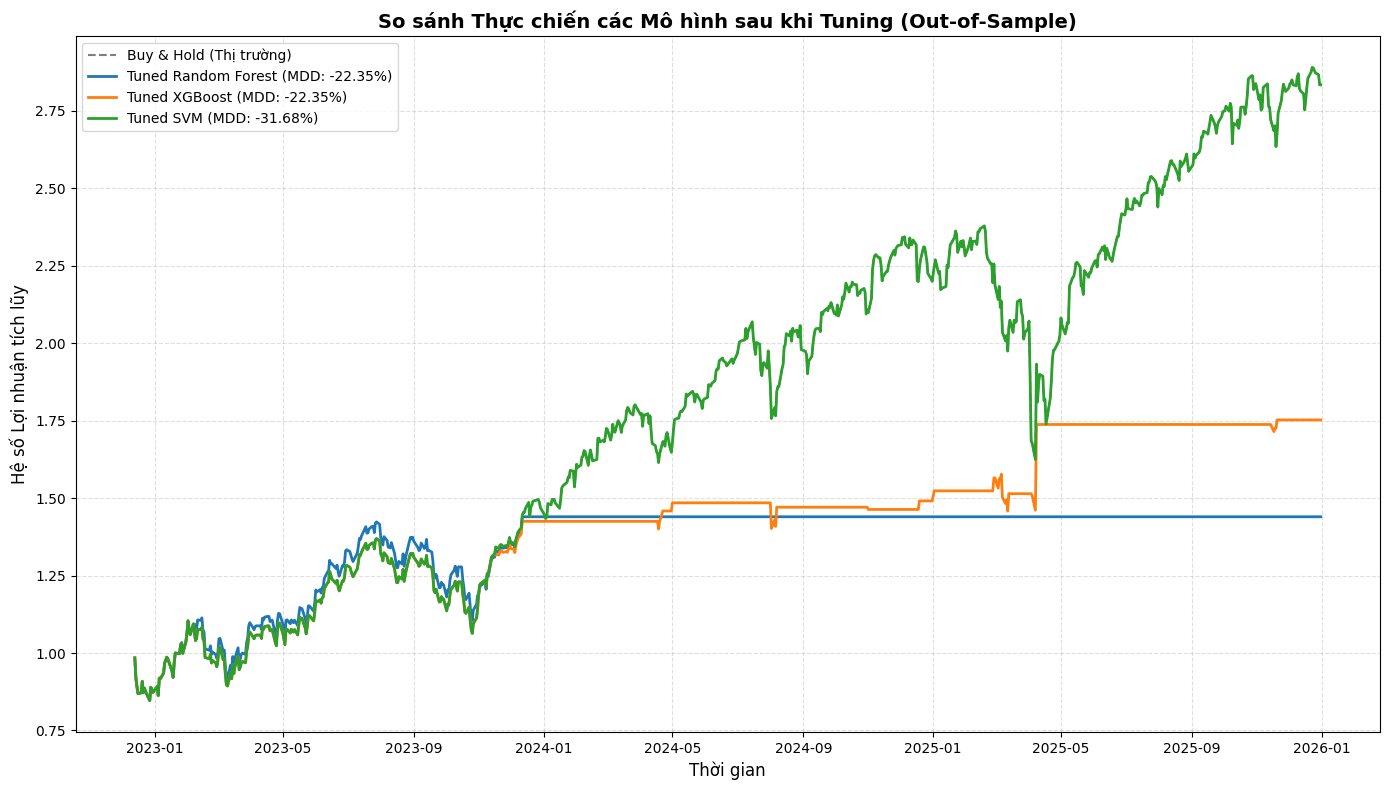

Max Drawdown Random Forest: -22.35%
Max Drawdown XGBoost:       -22.35%
Max Drawdown SVM:           -31.68%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đảm bảo dữ liệu đã được tải (Phòng trường hợp kernel reset)
train_df = pd.read_csv('sp500_train_80.csv', index_col='Date', parse_dates=True)
test_df = pd.read_csv('sp500_test_20.csv', index_col='Date', parse_dates=True)

# Tách lại features nếu cần
X_test = test_df.drop(columns=['Target_1D', 'Target_5D'])
y_test = test_df['Target_1D']

# Tính toán tỷ suất sinh lời thực tế (Benchmark)
real_returns = test_df['Close'].pct_change().shift(-1).fillna(0)
test_dates = test_df.index
cumulative_market = (1 + real_returns).cumprod()

# 2. Lấy dự đoán từ các mô hình đã TỐI ƯU HÓA
# (Giả định best_rf_model, best_xgb_model, best_svm_model đã được fit ở các cell trước)
y_pred_rf_tuned = best_rf_model.predict(X_test)
y_pred_xgb_tuned = best_xgb_model.predict(X_test)
y_pred_svm_tuned = best_svm_model.predict(X_test)

# 3. Tính toán lợi nhuận tích lũy cho từng chiến lược
strategy_rf = (1 + (y_pred_rf_tuned * real_returns)).cumprod()
strategy_xgb = (1 + (y_pred_xgb_tuned * real_returns)).cumprod()
strategy_svm = (1 + (y_pred_svm_tuned * real_returns)).cumprod()

# 4. Hàm tính Max Drawdown
def get_max_drawdown(cumulative_series):
    rolling_max = cumulative_series.cummax()
    drawdown = cumulative_series / rolling_max - 1.0
    return drawdown.min()

mdd_rf = get_max_drawdown(strategy_rf)
mdd_xgb = get_max_drawdown(strategy_xgb)
mdd_svm = get_max_drawdown(strategy_svm)

# 5. Vẽ biểu đồ so sánh tổng hợp
plt.figure(figsize=(14, 8))

plt.plot(test_dates, cumulative_market, label='Buy & Hold (Thị trường)', color='black', linestyle='--', alpha=0.5)
plt.plot(test_dates, strategy_rf, label=f'Tuned Random Forest (MDD: {mdd_rf:.2%})', linewidth=2)
plt.plot(test_dates, strategy_xgb, label=f'Tuned XGBoost (MDD: {mdd_xgb:.2%})', linewidth=2)
plt.plot(test_dates, strategy_svm, label=f'Tuned SVM (MDD: {mdd_svm:.2%})', linewidth=2)

plt.title('So sánh Thực chiến các Mô hình sau khi Tuning (Out-of-Sample)', fontsize=14, fontweight='bold')
plt.ylabel('Hệ số Lợi nhuận tích lũy', fontsize=12)
plt.xlabel('Thời gian', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Lưu lại ảnh
plt.savefig('all_models_tuned_comparison.png', dpi=300)
plt.show()

print(f"Max Drawdown Random Forest: {mdd_rf:.2%}")
print(f"Max Drawdown XGBoost:       {mdd_xgb:.2%}")
print(f"Max Drawdown SVM:           {mdd_svm:.2%}")